# DBT-UNet
Barlow Twins with a **dense decoder term**, so self-supervised pretraining covers the whole U-Net instead of the encoder only.

**What is different from BT-UNet.** `build_encoder` in the BT-UNet notebook stops at the bottleneck and global-average-pools, so only encoder weights ever transfer and the decoder is randomly initialised at fine-tuning time. Here the trunk runs the decoder as well and hangs a second projection head off its output. Total objective:

$$L = L_{global} + \beta \cdot L_{dense}$$

`BETA = 0` recovers the BT-UNet objective on the identical global head, so it is the control arm and every comparison is one term switched on or off. Nothing else changes between arms.

**Why the dense term should help twice over.** Barlow Twins estimates a $D \times D$ cross-correlation matrix from $N$ samples. The global branch has $N$ = batch size = 8 by default, which is badly under-determined and is the most plausible reason `--batch 64` was the largest effect that replicated across both datasets in the ablation sweep. The dense branch reshapes $(B, H, W, D)$ to $(B \cdot H \cdot W, D)$, so at 128x128 with stride 4 the same matrix gets 8192 samples.

**Pipeline:**
1. Pretrain the full U-Net trunk with global + dense Barlow Twins (no labels)
2. Transfer encoder **and** decoder, attach a fresh output layer, fine-tune at each label fraction (1%, 5%, 10%, 20%, 50%)
3. K-fold CV and ensembling, identical to the other three notebooks

## Configuration

In [19]:
# ============================================================
# CONFIGURATION
# ============================================================
# Change paths depending on dataset

DATASET_NAME = "KDSB"

DATASET_CONFIGS = {
    "KDSB": {
        "train_path": "datasets/KDSB/train/",
        "val_path":   "datasets/KDSB/val/",       # doesn't exist for KDSB -> HAS_VAL will be False
        "test_path":  "datasets/KDSB/test/",
        "img_dir":    "org",             # subfolder holding images, relative to each split path
        "mask_dir":   "gt",              # subfolder holding masks, relative to each split path
        "mask_name":  lambda img_name: img_name,
    },
       "ISIC2018": {
        "train_path": "datasets/ISIC2018/train/",
        "val_path":   "datasets/ISIC2018/val/",
        "test_path":  "datasets/ISIC2018/test/",
        "img_dir":    "org",
        "mask_dir":   "gt",
        "mask_name":  lambda img_name: os.path.splitext(img_name)[0] + "_segmentation.png",
    },
}

import os
cfg = DATASET_CONFIGS[DATASET_NAME]
TRAIN_PATH   = cfg["train_path"]
VAL_PATH     = cfg["val_path"]
TEST_PATH    = cfg["test_path"]
IMG_DIR      = cfg["img_dir"]
MASK_DIR     = cfg["mask_dir"]
mask_name_fn = cfg["mask_name"]


SAVE_DIR     = "saved_models"
SAVE_NP      = "saved_np"

IMG_HEIGHT   = 256
IMG_WIDTH    = 256
IMG_CHANNELS = 3

# 1% added: it is where the SSL advantage is largest, and the ablation sweep
# only ever ran `frozen` there.
LABEL_FRACTIONS = [0.05, 0.10, 0.20, 0.50]

val_split  = 0.3
THRESHOLD  = 0.5

FAMILY = "DBT-UNet"

# ---- The arm this run trains -------------------------------------------------
# BETA = 0.0 is the control. Name it "base" rather than "b0": ablation_report.py
# only computes deltas against a variant literally called base, so anything else
# makes the whole model group vanish from the report without a warning.
BETA    = 1.0
VARIANT = "b1"        # control arm: BETA = 0.0, VARIANT = "base"

# Dense Barlow Twins pretraining
PRETRAIN_EPOCHS    = 100
PRETRAIN_BATCH     = 8
PRETRAIN_SIZE      = IMG_HEIGHT   # set 128 to quarter activation memory and afford a bigger batch
PROJECT_DIM        = IMG_HEIGHT // 2   # 128, same as BT-UNet
DENSE_DIM          = 128
DENSE_STRIDE       = 4     # spatial subsampling before the dense loss
DENSE_LAMBD        = None  # None -> same as LAMBD
LAMBD              = 5e-3
WEIGHT_DECAY       = 5e-4
PRETRAIN_FLG       = True  # False = load the saved trunk
PRETRAINED_WEIGHTS = f"{DATASET_NAME}_dense_barlow_twins_{VARIANT}_trunk.keras"

# Segmentation fine-tuning
FINETUNE_EPOCHS = 200
FINETUNE_BATCH  = 8
TRAIN_FLG       = True      # False = skip fine-tuning
FREEZE_ENCODER  = False
FREEZE_DECODER  = False     # both True = linear probe on the output layer alone

# TEST_MODE: set True to smoke-test the full pipeline cheaply
TEST_MODE = False

# ---- K-Fold Cross-Validation ----
USE_KFOLD       = True
N_FOLDS         = 5
CV_RANDOM_STATE = 42
RECALL_FLOOR    = 0.05

## Imports

In [20]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"   # must be set BEFORE tensorflow is imported
import random
import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from skimage.io import imread, imshow
from skimage.morphology import label
from skimage.transform import resize
from sklearn.model_selection import KFold

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import *
from tensorflow.keras.metrics import Accuracy, Precision, Recall, MeanIoU, MeanAbsoluteError
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import binary_crossentropy, categorical_crossentropy
from tensorflow.python.ops import array_ops
from hausdorff import hausdorff_distance

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(SAVE_NP,  exist_ok=True)
os.makedirs("logs/fit", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [21]:
# ============================================================
# GPU CONFIGURATION / DIAGNOSTICS
# ============================================================
import subprocess

try:
    print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)
except FileNotFoundError:
    print('nvidia-smi not found — NVIDIA driver may not be installed/visible on this machine.')

gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow build info: {tf.sysconfig.get_build_info().get("cuda_version", "n/a")=} '
      f'{tf.sysconfig.get_build_info().get("cudnn_version", "n/a")=}')
print('TensorFlow version:', tf.__version__)
print('GPUs visible to TensorFlow:', gpus)

if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(e)
    print(f'Memory growth enabled on {len(gpus)} GPU(s). Training will use the GPU automatically.')
else:
    print(
        'No GPU detected by TensorFlow. If nvidia-smi above shows a GPU but this list is empty, '
        'the installed TensorFlow build likely lacks CUDA support. Fix with:\n'
        '  pip uninstall tensorflow -y\n'
        '  pip install tensorflow[and-cuda]\n'
        'Then restart the kernel and re-run this cell.'
    )

Tue Aug 25 18:15:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.173.02             Driver Version: 580.173.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro RTX 6000                Off |   00000000:01:00.0 Off |                  Off |
| 35%   50C    P8             30W /  260W |      16MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Data Loading
Byte-identical to the other three notebooks, so the cached `.npy` arrays are reused rather than rebuilt.

In [22]:
# ---- Detect whether this dataset ships a dedicated validation split ----
HAS_VAL = os.path.isdir(os.path.join(VAL_PATH, IMG_DIR))
print(f"Validation folder found at {VAL_PATH} — will use it for validation."
      if HAS_VAL else
      "No validation folder found — will fall back to splitting train data (val_split).")

x_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
x_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")

if HAS_VAL:
    x_val_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_val_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
    y_val_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_val_{IMG_HEIGHT}x{IMG_WIDTH}.npy")

required_paths = [x_train_path, y_train_path, x_test_path, y_test_path]
if HAS_VAL:
    required_paths += [x_val_path, y_val_path]

def load_split(split_path):
    """Load and resize one split's images + masks using this dataset's naming convention."""
    ids = next(os.walk(os.path.join(split_path, IMG_DIR)))[2][:]
    X = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y = np.zeros((len(ids), IMG_HEIGHT, IMG_WIDTH, 1),            dtype=np.float32)

    for n, id_ in tqdm(enumerate(ids), total=len(ids)):
        img = imread(os.path.join(split_path, IMG_DIR, id_))[:, :, :IMG_CHANNELS]
        img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
        X[n] = img

        mask = imread(os.path.join(split_path, MASK_DIR, mask_name_fn(id_)))
        mask = np.expand_dims(mask, axis=-1)
        mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH, 1), mode='constant', preserve_range=True)
        Y[n][mask[:, :, 0] / 255 > 0.] = 1.

    return X, Y

if all(os.path.exists(p) for p in required_paths):
    print("Found cached arrays, loading...")
    X_train = np.load(x_train_path)
    Y_train = np.load(y_train_path)
    X_test  = np.load(x_test_path)
    Y_test  = np.load(y_test_path)
    if HAS_VAL:
        X_val = np.load(x_val_path)
        Y_val = np.load(y_val_path)
        print(f"Loaded — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    else:
        X_val, Y_val = None, None
        print(f"Loaded — Train: {X_train.shape}, Test: {X_test.shape}")

else:
    print("No cached arrays found, loading and resizing from disk...")

    X_train, Y_train = load_split(TRAIN_PATH)
    X_test,  Y_test  = load_split(TEST_PATH)
    print(f"Train images: {X_train.shape[0]}, Test images: {X_test.shape[0]}")

    np.save(x_train_path, X_train)
    np.save(y_train_path, Y_train)
    np.save(x_test_path,  X_test)
    np.save(y_test_path,  Y_test)

    if HAS_VAL:
        X_val, Y_val = load_split(VAL_PATH)
        print(f"Val images: {X_val.shape[0]}")
        np.save(x_val_path, X_val)
        np.save(y_val_path, Y_val)
        print(f"Saved — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    else:
        X_val, Y_val = None, None
        print(f"Saved — Train: {X_train.shape}, Test: {X_test.shape}")

# How many images each fraction actually gets. At 1% this is a handful, which is
# the whole reason a randomly initialised decoder is a problem.
for f in LABEL_FRACTIONS:
    print(f"  {int(f*100):>2}% labelled -> {int(X_train.shape[0]*f)} images")

Validation folder found at datasets/KDSB/val/ — will use it for validation.
Found cached arrays, loading...
Loaded — Train: (514, 256, 256, 3), Val: (110, 256, 256, 3), Test: (111, 256, 256, 3)
   5% labelled -> 25 images
  10% labelled -> 51 images
  20% labelled -> 102 images
  50% labelled -> 257 images


## U-Net Architecture
Identical to BT-UNet, SimSiam-UNet and baseline UNet notebooks. Layer names matter here: the trunk-to-segmentation weight transfer matches on them.

In [23]:
def double_conv_layer(x, filter_size, size, dropout, batch_norm=False, prefix="dec"):
    axis = 3
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same',
                            name=f'{prefix}_sepconv_a')(x)
    if batch_norm:
        conv = BatchNormalization(axis=axis, name=f'{prefix}_bn_a')(conv)
    conv = Activation('relu', name=f'{prefix}_relu_a')(conv)
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same',
                            name=f'{prefix}_sepconv_b')(conv)
    if batch_norm:
        conv = BatchNormalization(axis=axis, name=f'{prefix}_bn_b')(conv)
    conv = Activation('relu', name=f'{prefix}_relu_b')(conv)
    if dropout > 0:
        conv = Dropout(dropout, name=f'{prefix}_drop')(conv)
    shortcut = Conv2D(size, kernel_size=(1, 1), padding='same', name=f'{prefix}_shortcut')(x)
    if batch_norm:
        shortcut = BatchNormalization(axis=axis, name=f'{prefix}_shortcut_bn')(shortcut)
    return add([shortcut, conv], name=f'{prefix}_add')


def encoder(inputs, prefix="enc"):
    num_filters = [16, 32, 64, 128]
    skip_connections = []
    x = inputs
    for i, f in enumerate(num_filters):
        stage = f'{prefix}_stage{i}'
        a = double_conv_layer(x, 3, f, 0.1, True, prefix=stage)
        skip_connections.append(a)
        x = MaxPooling2D(pool_size=(2, 2), name=f'{stage}_pool')(a)
    return x, skip_connections


def bottleneck(inputs, prefix="bneck"):
    return double_conv_layer(inputs, 3, 256, 0.1, True, prefix=prefix)


def decoder(inputs, skip_connections, prefix="dec"):
    num_filters = [128, 64, 32, 16]
    skip_connections = skip_connections[::-1]
    x = inputs
    for i, f in enumerate(num_filters):
        stage = f'{prefix}_stage{i}'
        x_up  = UpSampling2D(size=(2, 2), data_format="channels_last", name=f'{stage}_up')(x)
        x_att = concatenate([x_up, skip_connections[i]], axis=-1, name=f'{stage}_concat')
        x     = double_conv_layer(x_att, 3, f, 0.1, True, prefix=stage)
    return x


def output(inputs, prefix="out"):
    x = Conv2D(1, kernel_size=(1, 1), name=f'{prefix}_conv')(inputs)
    x = BatchNormalization(name=f'{prefix}_bn')(x)
    x = Activation('sigmoid', name=f'{prefix}_sigmoid')(x)
    return x


# The decoder prefix is fixed rather than derived from the keyname, because the
# decoder weights now have to match names with the saved trunk. BT-UNet used
# f'{keyname}_dec', which was fine when the decoder was never transferred.
DECODER_PREFIX      = "dec"
TRANSFER_PREFIXES   = ("enc_", "bneck_", f"{DECODER_PREFIX}_")

## Dense Barlow Twins Pretraining

**How the global term works** (unchanged from BT-UNet): two augmented views pass through the shared trunk, and the cross-correlation matrix between the two pooled embeddings is pushed toward the identity. Diagonal toward 1 for invariance, off-diagonal toward 0 for redundancy reduction. No negative pairs, no momentum encoder.

**How the dense term works:** the same objective, but each spatial position in the decoder output is a sample instead of pooling everything into one vector. Channels stay the feature axis, so the matrix is still `DENSE_DIM x DENSE_DIM`.

**Positions have to correspond.** Position `(i, j)` in view A must describe the same patch of the original image as `(i, j)` in view B, or the loss compares unrelated pixels and produces a plausible number that means nothing. Two changes to the augmentation buy that:

- **The crop is sampled once and shared by both views.** BT-UNet draws two independent random-resized-crops. A crop is not exactly invertible on a feature map, so independent crops leave no recoverable correspondence.
- **Flips and rot90 stay independent per view** and are undone on the decoder feature map before the loss. Both are exact spatial permutations, so inverting them costs nothing.

Colour jitter stays independent per view and needs no inverse, since it does not move pixels.

This *is* a change to the augmentation distribution relative to BT-UNet, which is exactly why the control arm is `BETA = 0` under this same augmentation and not the original BT-UNet run. `BETA = 0` isolates the dense loss; `BETA = 0` versus the original BT-UNet run isolates the augmentation change. Report both.

### Augmentation Pipeline (aligned pairs)

In [24]:
CROP_TO = PRETRAIN_SIZE
AUTO    = tf.data.AUTOTUNE
SEED    = 42

def random_resize_crop(image, scale=[0.75, 1.0], crop_size=None):
    crop_size   = crop_size or CROP_TO
    image_shape = crop_size
    image = tf.image.resize(image, (image_shape, image_shape))
    size  = tf.random.uniform(shape=(1,), minval=scale[0]*image_shape,
                              maxval=scale[1]*image_shape, dtype=tf.float32)
    size  = tf.cast(size, tf.int32)[0]
    crop  = tf.image.random_crop(image, (size, size, 3))
    return tf.image.resize(crop, (crop_size, crop_size))

def color_jitter(x, strength=0.5):
    x = tf.image.random_brightness(x, max_delta=0.8 * strength)
    x = tf.image.random_contrast(x, lower=1-0.8*strength, upper=1+0.8*strength)
    x = tf.image.random_saturation(x, lower=1-0.8*strength, upper=1+0.8*strength)
    x = tf.image.random_hue(x, max_delta=0.2 * strength)
    return tf.clip_by_value(x, 0, 255)

def random_apply(func, x, p):
    # tf.cond rather than a Python if: under tf.data tracing the Python branch
    # would be evaluated once at trace time and then frozen for every image.
    return tf.cond(tf.random.uniform([], 0, 1) < p, lambda: func(x), lambda: x)


def one_view(base):
    """Geometry first, then photometry, so the returned flip/k describe the whole
    spatial transform and nothing else moved pixels afterwards."""
    x    = base
    flip = tf.random.uniform([], 0, 2, dtype=tf.int32)
    x    = tf.cond(tf.equal(flip, 1), lambda: tf.image.flip_left_right(x), lambda: x)

    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    x = tf.image.rot90(x, k=k)

    x = random_apply(color_jitter, x, p=0.8)
    # 0.8 rather than the reference implementation's 0.9, matching the BT-UNet
    # and SimSiam notebooks so the three stay comparable.
    return x, flip, k


def augment_pair(image):
    """image -> (view_a, flip_a, k_a, view_b, flip_b, k_b)"""
    image = tf.cast(image, tf.float32)
    base  = random_resize_crop(image)      # sampled ONCE, shared by both views
    v_a, f_a, k_a = one_view(base)
    v_b, f_b, k_b = one_view(base)
    return v_a, f_a, k_a, v_b, f_b, k_b


# One shuffle, one map, both views from the same source image. BT-UNet zips two
# independently shuffled datasets and relies on both being handed the same seed
# to line the images up; that works, but it is load-bearing and invisible.
ssl_ds = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(1024, seed=SEED)
    .map(augment_pair, num_parallel_calls=AUTO)
    .batch(PRETRAIN_BATCH)
    .prefetch(AUTO)
)

_dense_positions = (PRETRAIN_SIZE // DENSE_STRIDE) ** 2 * PRETRAIN_BATCH
print(f"Global term: {PRETRAIN_BATCH} samples for a {PROJECT_DIM}x{PROJECT_DIM} correlation matrix")
print(f"Dense term:  {_dense_positions:,} positions for a {DENSE_DIM}x{DENSE_DIM} matrix "
      f"(stride {DENSE_STRIDE})")

Global term: 8 samples for a 128x128 correlation matrix
Dense term:  32,768 positions for a 128x128 matrix (stride 4)


### LR Schedule (WarmUp + Cosine Decay)
Identical to BT-UNet and SimSiam-UNet notebooks.

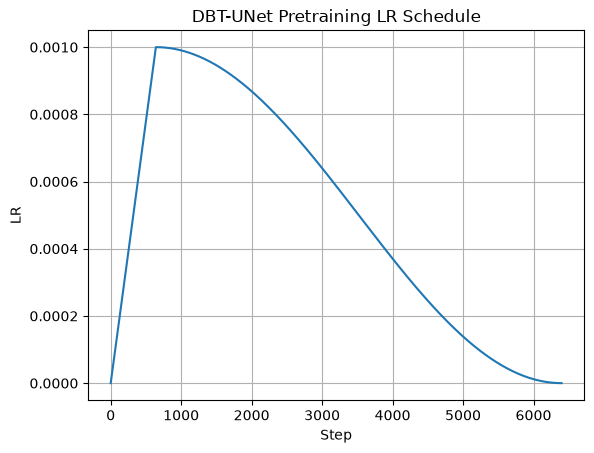

In [25]:
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps):
        super().__init__()
        self.learning_rate_base   = learning_rate_base
        self.total_steps          = total_steps
        self.warmup_learning_rate = warmup_learning_rate
        self.warmup_steps         = warmup_steps
        self.pi                   = tf.constant(np.pi)

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
            raise ValueError("total_steps must be >= warmup_steps")
        lr = (0.5 * self.learning_rate_base *
              (1 + tf.cos(self.pi * (tf.cast(step, tf.float32) - self.warmup_steps)
                          / float(self.total_steps - self.warmup_steps))))
        if self.warmup_steps > 0:
            slope       = (self.learning_rate_base - self.warmup_learning_rate) / self.warmup_steps
            warmup_rate = slope * tf.cast(step, tf.float32) + self.warmup_learning_rate
            lr          = tf.where(step < self.warmup_steps, warmup_rate, lr)
        return tf.where(step > self.total_steps, 0.0, lr)


STEPS_PER_EPOCH = len(X_train) // PRETRAIN_BATCH
TOTAL_STEPS     = STEPS_PER_EPOCH * PRETRAIN_EPOCHS
WARMUP_STEPS    = int(PRETRAIN_EPOCHS * 0.1) * STEPS_PER_EPOCH

lr_decayed_fn = WarmUpCosine(
    learning_rate_base=1e-3,
    total_steps=TOTAL_STEPS,
    warmup_learning_rate=0.0,
    warmup_steps=WARMUP_STEPS,
)

plt.plot(lr_decayed_fn(tf.range(TOTAL_STEPS, dtype=tf.float32)))
plt.title("DBT-UNet Pretraining LR Schedule")
plt.xlabel("Step")
plt.ylabel("LR")
plt.grid()
plt.show()

### Trunk + Both Projection Heads

The global head is the same `projection_head` as BT-UNet's, layer names included, so `BETA = 0` is a real control and not merely an equivalent one.

The dense head has to exist at all because the decoder output carries **16 channels** (`decoder`'s `num_filters` ends at 16). A 16x16 cross-correlation matrix is too small for a redundancy-reduction objective to say anything, so 1x1 convolutions lift it to `DENSE_DIM`, exactly as the global head lifts the 256-channel bottleneck.

In [26]:
def projection_head(x, hidden_dim=128):
    """Verbatim from BT-UNet, names included."""
    for i in range(2):
        x = Dense(hidden_dim, kernel_regularizer=l2(WEIGHT_DECAY),
                  name=f"projection_layer_{i}")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
    x = Dense(hidden_dim, name="projection_output")(x)
    return x


def dense_projection_head(x, hidden_dim=128, prefix="dense_projection"):
    """projection_head applied per spatial position, i.e. 1x1 convolutions."""
    for i in range(2):
        x = Conv2D(hidden_dim, 1, padding='same', name=f'{prefix}_layer_{i}')(x)
        x = BatchNormalization(name=f'{prefix}_bn_{i}')(x)
        x = Activation('relu', name=f'{prefix}_relu_{i}')(x)
    return Conv2D(hidden_dim, 1, padding='same', name=f'{prefix}_output')(x)


def build_dbt_unet(img_size=None, hidden_dim=128, dense_dim=128):
    """Full U-Net trunk with two heads.

    img_size defaults to PRETRAIN_SIZE. Pretraining at 128 while fine-tuning at
    256 is safe because weights move by layer name, not by saved graph: every
    layer is convolutional or normalisation, so no weight shape depends on the
    spatial size.
    """
    size   = img_size or PRETRAIN_SIZE
    inputs = Input((size, size, IMG_CHANNELS))
    s      = layers.Rescaling(1.0 / 255)(inputs)

    x, skip_connections = encoder(s)
    x = bottleneck(x)
    d = decoder(x, skip_connections, prefix=DECODER_PREFIX)

    global_out = projection_head(GlobalAvgPool2D()(x), hidden_dim=hidden_dim)
    dense_out  = dense_projection_head(d, hidden_dim=dense_dim)

    return Model(inputs, [global_out, dense_out], name="dbt_unet")


dbt_trunk = build_dbt_unet(hidden_dim=PROJECT_DIM, dense_dim=DENSE_DIM)
dbt_trunk.summary()

Model: "dbt_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_sepconv… │ (None, 256, 256,  │         91 │ rescaling[0][0]   │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_bn_a     │ (None, 256, 256,  │         64 │ enc_stage0_sepco… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_relu_a   │ (None, 256, 256,  │          0 │ enc_stage0_bn_a[… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_sepconv… │ (None, 256, 256,  │        416 │ enc_stage0_relu_… │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_bn_b     │ (None, 256, 256,  │         64 │ enc_stage0_sepco… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_shortcut │ (None, 256, 256,  │         64 │ rescaling[0][0]   │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_relu_b   │ (None, 256, 256,  │          0 │ enc_stage0_bn_b[… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_shortcu… │ (None, 256, 256,  │         64 │ enc_stage0_short… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_drop     │ (None, 256, 256,  │          0 │ enc_stage0_relu_… │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_add      │ (None, 256, 256,  │          0 │ enc_stage0_short… │
│ (Add)               │ 16)               │            │ enc_stage0_drop[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage0_pool     │ (None, 128, 128,  │          0 │ enc_stage0_add[0… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage1_sepconv… │ (None, 128, 128,  │        688 │ enc_stage0_pool[… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage1_bn_a     │ (None, 128, 128,  │        128 │ enc_stage1_sepco… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage1_relu_a   │ (None, 128, 128,  │          0 │ enc_stage1_bn_a[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_stage1_sepconv… │ (None, 128, 128,  │      1,344 │ enc_stage1_relu_

 Total params: 456,251 (1.74 MB)

 Trainable params: 450,811 (1.72 MB)

 Non-trainable params: 5,440 (21.25 KB)

### Dense Barlow Twins Model

In [27]:
def off_diagonal(x):
    n = tf.shape(x)[0]
    flattened = tf.reshape(x, [-1])[:-1]
    off_diagonals = tf.reshape(flattened, (n-1, n+1))[:, 1:]
    return tf.reshape(off_diagonals, [-1])

def normalize_repr(z):
    return (z - tf.reduce_mean(z, axis=0)) / tf.math.reduce_std(z, axis=0)

def compute_loss(z_a, z_b, lambd):
    """Global term. Verbatim from BT-UNet — left untouched on purpose so BETA=0
    reproduces that objective bit for bit."""
    batch_size = tf.cast(tf.shape(z_a)[0], z_a.dtype)
    z_a_norm = normalize_repr(z_a)
    z_b_norm = normalize_repr(z_b)
    c = tf.matmul(z_a_norm, z_b_norm, transpose_a=True) / batch_size
    on_diag  = tf.reduce_sum(tf.pow(tf.linalg.diag_part(c) + (-1), 2))
    off_diag = tf.reduce_sum(tf.pow(off_diagonal(c), 2))
    return on_diag + (lambd * off_diag)


def undo_geometry(feat, flip, k):
    """Map a decoder feature map back to the pre-augmentation spatial frame.

    The forward transform was rot90_k(flip(x)), so the inverse is
    flip(rot90_{-k}(y)) applied in that order. flip_left_right is its own
    inverse. Both operations are exact on a feature map: they only permute
    spatial positions.

    Per-sample, hence map_fn — flip and k differ within a batch. If this shows
    up in a profile, the fix is to share geometry across the batch, at the cost
    of augmentation diversity.
    """
    def per_sample(args):
        f, fl, kk = args
        f = tf.image.rot90(f, k=(4 - kk) % 4)
        f = tf.cond(tf.equal(fl, 1), lambda: tf.image.flip_left_right(f), lambda: f)
        return f
    return tf.map_fn(per_sample, (feat, flip, k), fn_output_signature=feat.dtype)


def compute_dense_loss(d_a, d_b, lambd, stride=4, eps=1e-6):
    """Barlow Twins over spatial positions.

    d_a and d_b must already sit in the same spatial frame — call undo_geometry
    first. Positions become the sample axis, channels stay the feature axis.

    eps is nonzero here where normalize_repr above has none. Not a correction to
    that function: it is left alone so the global term stays identical to
    BT-UNet's. With thousands of samples a dead channel is far more likely than
    with eight, and dividing by its zero standard deviation would NaN the run.
    """
    if stride > 1:
        d_a = d_a[:, ::stride, ::stride, :]
        d_b = d_b[:, ::stride, ::stride, :]

    dim = tf.shape(d_a)[-1]
    z_a = tf.reshape(d_a, (-1, dim))
    z_b = tf.reshape(d_b, (-1, dim))
    n   = tf.cast(tf.shape(z_a)[0], z_a.dtype)

    z_a = (z_a - tf.reduce_mean(z_a, axis=0)) / (tf.math.reduce_std(z_a, axis=0) + eps)
    z_b = (z_b - tf.reduce_mean(z_b, axis=0)) / (tf.math.reduce_std(z_b, axis=0) + eps)

    c = tf.matmul(z_a, z_b, transpose_a=True) / n
    on_diag  = tf.reduce_sum(tf.pow(tf.linalg.diag_part(c) + (-1), 2))
    off_diag = tf.reduce_sum(tf.pow(off_diagonal(c), 2))
    return on_diag + (lambd * off_diag)


class DenseBarlowTwins(tf.keras.Model):
    """L_global + beta * L_dense.

    The two components are tracked separately because their scales are set
    independently by PROJECT_DIM and DENSE_DIM. A beta that looks reasonable can
    still leave one term two orders of magnitude below the other, and that is
    invisible in the total. Watch both curves before trusting any beta.
    """

    def __init__(self, trunk, lambd=5e-3, beta=1.0, dense_lambd=None, dense_stride=4):
        super().__init__()
        self.trunk           = trunk
        self.lambd           = lambd
        self.beta            = beta
        self.dense_lambd     = lambd if dense_lambd is None else dense_lambd
        self.dense_stride    = dense_stride
        self.loss_tracker    = tf.keras.metrics.Mean(name="loss")
        self.global_tracker  = tf.keras.metrics.Mean(name="global")
        self.dense_tracker   = tf.keras.metrics.Mean(name="dense")

    @property
    def metrics(self):
        return [self.loss_tracker, self.global_tracker, self.dense_tracker]

    def train_step(self, data):
        view_a, flip_a, k_a, view_b, flip_b, k_b = data

        with tf.GradientTape() as tape:
            g_a, d_a = self.trunk(view_a, training=True)
            g_b, d_b = self.trunk(view_b, training=True)

            loss_global = compute_loss(g_a, g_b, self.lambd)

            d_a = undo_geometry(d_a, flip_a, k_a)
            d_b = undo_geometry(d_b, flip_b, k_b)
            loss_dense = compute_dense_loss(d_a, d_b, self.dense_lambd,
                                            stride=self.dense_stride)

            loss = loss_global + self.beta * loss_dense

        gradients = tape.gradient(loss, self.trunk.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trunk.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.global_tracker.update_state(loss_global)
        self.dense_tracker.update_state(loss_dense)
        return {"loss":   self.loss_tracker.result(),
                "global": self.global_tracker.result(),
                "dense":  self.dense_tracker.result()}

### Sanity Checks

Run this before committing GPU hours. Each check targets something that fails **silently** rather than raising:

- a wrong geometry inverse makes the dense loss compare mismatched pixels and still produce a smooth, plausible-looking curve
- a `BETA = 0` arm that quietly trains the decoder is not a control, and every delta computed against it is contaminated
- a global head that has drifted from BT-UNet's means the arms differ by more than one term

Seconds to run on CPU.

In [28]:
def _sanity_checks():
    ok = []

    # 1. undo_geometry is exact for all eight flip/rot90 combinations
    base = np.random.default_rng(0).random((3, 8, 8, 5)).astype(np.float32)
    for flip in (0, 1):
        for k in range(4):
            x = tf.constant(base)
            if flip == 1:
                x = tf.image.flip_left_right(x)
            x = tf.image.rot90(x, k=k)
            back = undo_geometry(x, tf.constant([flip]*3, tf.int32), tf.constant([k]*3, tf.int32))
            assert np.allclose(back.numpy(), base), f"undo_geometry wrong for flip={flip} k={k}"
    ok.append("undo_geometry inverts every flip/rot90 combination")

    # 2. per-sample, because flip and k differ within a batch
    b2 = np.random.default_rng(1).random((4, 8, 8, 3)).astype(np.float32)
    flips, ks, views = [0, 1, 1, 0], [0, 1, 2, 3], []
    for i in range(4):
        x = tf.constant(b2[i:i+1])
        if flips[i] == 1:
            x = tf.image.flip_left_right(x)
        views.append(tf.image.rot90(x, k=ks[i]))
    back = undo_geometry(tf.concat(views, 0), tf.constant(flips, tf.int32),
                         tf.constant(ks, tf.int32))
    assert np.allclose(back.numpy(), b2), "undo_geometry is not per-sample"
    ok.append("undo_geometry handles mixed geometry within one batch")

    # 3. the dense loss separates matched from mismatched views
    rng = np.random.default_rng(2)
    z     = rng.standard_normal((2, 16, 16, 32)).astype(np.float32)
    other = rng.standard_normal((2, 16, 16, 32)).astype(np.float32)
    same = float(compute_dense_loss(tf.constant(z), tf.constant(z), 5e-3, stride=1))
    diff = float(compute_dense_loss(tf.constant(z), tf.constant(other), 5e-3, stride=1))
    assert same < 1.0 and diff > same * 5, (same, diff)
    ok.append(f"dense loss: matched={same:.4f}  mismatched={diff:.2f}")

    # 4. a dead channel must not NaN the run
    zd = rng.standard_normal((2, 8, 8, 16)).astype(np.float32)
    zd[..., 0] = 0.0
    assert np.isfinite(float(compute_dense_loss(tf.constant(zd), tf.constant(zd), 5e-3, stride=1)))
    ok.append("dense loss stays finite with a dead channel")

    # 5. the global head still matches BT-UNet's, name for name
    heads = [l.name for l in dbt_trunk.layers if l.name.startswith("projection")]
    assert heads == ["projection_layer_0", "projection_layer_1", "projection_output"], heads
    ok.append("global head is name-identical to BT-UNet's")

    # 6. beta=0 must leave the decoder untouched, beta>0 must move it
       # random_resize_crop reads the CROP_TO global, which is PRETRAIN_SIZE. The
    # check builds a 32x32 trunk to stay cheap, so CROP_TO has to match for the
    # duration or augment_pair hands the trunk full-size images.
    global CROP_TO
    _crop_to_real = CROP_TO
    try:
        CROP_TO = 32
        for beta, should_move in ((0.0, False), (1.0, True)):
            t   = build_dbt_unet(img_size=32, hidden_dim=32, dense_dim=32)
            m   = DenseBarlowTwins(t, beta=beta, dense_stride=2)
            m.compile(optimizer=SGD(learning_rate=0.1, momentum=0.9))
            w0  = [w.numpy().copy() for w in t.get_layer("dec_stage0_sepconv_a").weights]
            Xs  = np.random.default_rng(5).integers(0, 255, (8, 40, 40, 3)).astype(np.float32)
            ds  = (tf.data.Dataset.from_tensor_slices(Xs).map(augment_pair).batch(4))
            m.fit(ds, epochs=1, verbose=0)
            w1    = [w.numpy() for w in t.get_layer("dec_stage0_sepconv_a").weights]
            moved = any(not np.allclose(a, b) for a, b in zip(w0, w1))
            assert moved == should_move, f"beta={beta}: decoder moved={moved}, expected {should_move}"
            del t, m
            tf.keras.backend.clear_session()
    finally:
        CROP_TO = _crop_to_real

    print("Sanity checks:")
    for line in ok:
        print(f"  ok    {line}")

_sanity_checks()

W0000 00:00:1787784592.930804  240552 assert_op.cc:39] Ignoring Assert operator map/while/rot90/Assert/AssertGuard/Assert
W0000 00:00:1787784592.952027  240552 assert_op.cc:39] Ignoring Assert operator map_1/while/rot90/Assert/AssertGuard/Assert
I0000 00:00:1787784594.942682  240552 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4436397__.587
W0000 00:00:1787784625.907290  240553 assert_op.cc:39] Ignoring Assert operator map/while/rot90/Assert/AssertGuard/Assert
W0000 00:00:1787784625.928364  240553 assert_op.cc:39] Ignoring Assert operator map_1/while/rot90/Assert/AssertGuard/Assert
I0000 00:00:1787784627.978574  240553 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4468182__.587


Sanity checks:
  ok    undo_geometry inverts every flip/rot90 combination
  ok    undo_geometry handles mixed geometry within one batch
  ok    dense loss: matched=0.0109  mismatched=32.19
  ok    dense loss stays finite with a dead channel
  ok    global head is name-identical to BT-UNet's


### Run Pretraining

Pretraining DBT-UNet trunk (beta=1.0, variant=b1)...
Epoch 1/100


W0000 00:00:1787784659.069243  240553 assert_op.cc:39] Ignoring Assert operator map/while/rot90/Assert/AssertGuard/Assert
W0000 00:00:1787784659.088363  240553 assert_op.cc:39] Ignoring Assert operator map_1/while/rot90/Assert/AssertGuard/Assert
I0000 00:00:1787784661.177184  240553 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4497677__.587


64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - dense: 54.0169 - global: 31.1302 - loss: 85.1471

W0000 00:00:1787784690.160976  240550 assert_op.cc:39] Ignoring Assert operator map/while/rot90/Assert/AssertGuard/Assert
W0000 00:00:1787784690.175206  240550 assert_op.cc:39] Ignoring Assert operator map_1/while/rot90/Assert/AssertGuard/Assert
I0000 00:00:1787784691.967408  240550 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4497677__.587


65/65 ━━━━━━━━━━━━━━━━━━━━ 65s 473ms/step - dense: 38.9506 - global: 29.3850 - loss: 68.3356
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - dense: 14.9331 - global: 24.8256 - loss: 39.7588
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - dense: 11.1277 - global: 23.9474 - loss: 35.0751
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - dense: 9.4677 - global: 23.4763 - loss: 32.9440
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - dense: 8.1967 - global: 21.5851 - loss: 29.7818
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - dense: 6.9195 - global: 24.4198 - loss: 31.3393
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - dense: 6.3624 - global: 22.4601 - loss: 28.8225
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - dense: 5.7718 - global: 21.3986 - loss: 27.1705
Epoch 9/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - dense: 5.1446 - global: 20.0862 - loss: 25.2308
Epoch 10/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - dense: 4.8448 - 

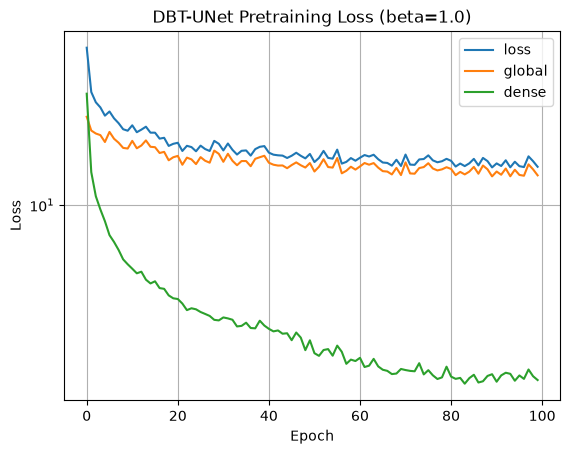

In [29]:
dbt = DenseBarlowTwins(dbt_trunk, lambd=LAMBD, beta=BETA,
                       dense_lambd=DENSE_LAMBD, dense_stride=DENSE_STRIDE)
dbt.compile(optimizer=SGD(learning_rate=lr_decayed_fn, momentum=0.9))

trunk_path = os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS)

if PRETRAIN_FLG:
    print(f"Pretraining DBT-UNet trunk (beta={BETA}, variant={VARIANT})...")
    pretrain_history = dbt.fit(ssl_ds, epochs=1 if TEST_MODE else PRETRAIN_EPOCHS)
    dbt.trunk.save(trunk_path)
    print(f"Saved trunk to {trunk_path}")

    # Both components on one axis on purpose. beta rescales the dense term, and a
    # beta that leaves one curve orders of magnitude below the other means only
    # one objective is actually training.
    for key in ("loss", "global", "dense"):
        plt.plot(pretrain_history.history[key], label=key)
    plt.title(f"DBT-UNet Pretraining Loss (beta={BETA})")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.yscale("symlog")
    plt.grid(); plt.legend(); plt.show()

    pd.DataFrame({
        "epoch":  range(1, len(pretrain_history.history["loss"]) + 1),
        "loss":   pretrain_history.history["loss"],
        "global": pretrain_history.history["global"],
        "dense":  pretrain_history.history["dense"],
    }).to_csv(os.path.join("results",
              f"{DATASET_NAME}_densebarlow_{VARIANT}_pretrain_loss.csv"), index=False)
else:
    print("Loading pretrained trunk...")
    dbt.trunk.load_weights(trunk_path)

## Metrics
Identical to the other three notebooks.

In [30]:
def iou_metric(y_true_in, y_pred_in):
    labels       = label(y_true_in > 0.5)
    y_pred       = label(y_pred_in > 0.5)
    true_objects = len(np.unique(labels))
    pred_objects = len(np.unique(y_pred))
    intersection = np.histogram2d(labels.flatten(), y_pred.flatten(),
                                  bins=(true_objects, pred_objects))[0]
    area_true    = np.expand_dims(np.histogram(labels, bins=true_objects)[0], -1)
    area_pred    = np.expand_dims(np.histogram(y_pred, bins=pred_objects)[0],  0)
    union        = area_true + area_pred - intersection
    intersection = intersection[1:, 1:]
    union        = union[1:, 1:]
    union[union == 0] = 1e-9
    iou = intersection / union

    def precision_at(threshold, iou):
        matches = iou > threshold
        tp = np.sum(np.sum(matches, axis=1) == 1)
        fp = np.sum(np.sum(matches, axis=0) == 0)
        fn = np.sum(np.sum(matches, axis=1) == 0)
        return tp, fp, fn

    prec = []
    for t in np.arange(0.5, 1.0, 0.05):
        tp, fp, fn = precision_at(t, iou)
        p = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        prec.append(p)
    return np.mean(prec)

def iou_metric_batch(y_true_in, y_pred_in):
    return sum(iou_metric(y_true_in[b], y_pred_in[b])
               for b in range(y_true_in.shape[0])) / y_true_in.shape[0]

def dice_coeff(y_true, y_pred):
    smooth       = 1.
    y_true_f     = K.flatten(y_true)
    y_pred_f     = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def haud_dist(y_true, y_pred):
    return hausdorff_distance(np.squeeze(y_true), np.squeeze(y_pred))

def haud_dist_batch(y_true, y_pred):
    if len(y_true.shape) == 2:
        return haud_dist(y_true, y_pred)
    return sum(haud_dist(y_true[b], y_pred[b]) for b in range(y_true.shape[0])) / y_true.shape[0]

def evalResult(gt, pred, num_class=2):
    gt   = np.squeeze(gt)
    pred = np.squeeze(pred)
    acc  = Accuracy();  acc.update_state(gt, pred);  r_acc = acc.result().numpy()
    pr   = Precision(); pr.update_state(gt, pred);   r_pr  = pr.result().numpy()
    rc   = Recall();    rc.update_state(gt, pred);   r_rc  = rc.result().numpy()
    mi   = MeanIoU(num_class); mi.update_state(gt, pred); r_mi = mi.result().numpy()
    dc   = sum(dice_coeff(gt[i], pred[i]).numpy() for i in range(gt.shape[0])) / gt.shape[0]
    hd   = haud_dist_batch(gt, pred)
    miou = iou_metric_batch(gt, pred)
    mae  = MeanAbsoluteError()
    r_mae = mae(gt, pred).numpy()
    print(f"  Acc={r_acc:.4f}  Prec={r_pr:.4f}  Rec={r_rc:.4f}  MeanIoU={r_mi:.4f}  "
          f"Dice={dc:.4f}  HD={hd:.4f}  MyIoU={miou:.4f}  MAE={r_mae:.4f}")
    return dict(Accuracy=r_acc, Precision=r_pr, Recall=r_rc,
                MeanIoU=r_mi, Dice=dc, HD=hd, MyIoU=miou, MAE=r_mae)

## Loss Functions

In [31]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return 0.4 * binary_crossentropy(y_true, y_pred) + 0.6 * dice_loss(y_true, y_pred)

## Fine-tuning — Encoder AND Decoder Transferred

BT-UNet cuts the saved encoder graph at `layers[-9]` and reads skips by layer index. That works only for the exact projection head that notebook builds, and it cannot transfer a decoder at all.

Here weights move **by layer name** into a freshly built U-Net instead. Two consequences worth knowing:

- a trunk pretrained at 128x128 can initialise a model that fine-tunes at 256x256, since no weight shape depends on spatial size
- the transfer can silently half-succeed if a name or filter count drifts, leaving part of the network randomly initialised while everything still runs and the only symptom is a slightly worse number, so `transfer_trunk_weights` **raises** rather than warning

The output layer stays randomly initialised. It is the one part of the network the SSL objective never sees.

In [32]:
def transfer_trunk_weights(dst, src, verbose=True):
    """Copy weights by layer name; refuse to continue if any expected layer missed."""
    src_by_name = {l.name: l for l in src.layers}
    copied, missing, mismatched = [], [], []

    for layer in dst.layers:
        if not layer.weights or not layer.name.startswith(TRANSFER_PREFIXES):
            continue
        source = src_by_name.get(layer.name)
        if source is None:
            missing.append(layer.name)
            continue
        if [w.shape for w in layer.get_weights()] != [w.shape for w in source.get_weights()]:
            mismatched.append(layer.name)
            continue
        layer.set_weights(source.get_weights())
        copied.append(layer.name)

    if missing or mismatched:
        raise RuntimeError(
            "Trunk weight transfer is incomplete.\n"
            f"  not found in trunk ({len(missing)}): {missing[:8]}\n"
            f"  shape mismatch ({len(mismatched)}): {mismatched[:8]}\n"
            "  The trunk was probably built with different filter counts or layer prefixes."
        )

    if verbose:
        n_dec = sum(1 for n in copied if n.startswith(f"{DECODER_PREFIX}_"))
        print(f"  Transferred {len(copied)} layers "
              f"({len(copied)-n_dec} encoder/bottleneck, {n_dec} decoder)")
    return copied


def build_segmentation_model(keyname, verbose=True):
    """Rebuild the full segmentation model fresh from the pretrained DBT trunk
    and compile it. Called once per fold and once per label fraction so every
    training run starts from identical pretrained weights."""
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    s = layers.Rescaling(1.0 / 255)(inputs)
    x, skip_connections = encoder(s)
    x = bottleneck(x)
    x = decoder(x, skip_connections, prefix=DECODER_PREFIX)
    outputs = output(x, prefix=f'{keyname}_out')
    model   = Model(inputs, outputs, name=keyname)

    trunk = tf.keras.models.load_model(os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS),
                                       compile=False)
    transfer_trunk_weights(model, trunk, verbose=verbose)
    del trunk

    # FREEZE_ENCODER also puts the encoder's BatchNormalization layers into
    # inference mode for the whole run. Report it as "frozen encoder incl. BN",
    # not "frozen weights".
    if FREEZE_ENCODER or FREEZE_DECODER:
        for layer in model.layers:
            if FREEZE_ENCODER and layer.name.startswith(("enc_", "bneck_")):
                layer.trainable = False
            if FREEZE_DECODER and layer.name.startswith(f"{DECODER_PREFIX}_"):
                layer.trainable = False

    model.compile(
        loss=bce_dice_loss,
        optimizer=Adam(),
        metrics=['accuracy', Precision(), MeanIoU(num_classes=2), Recall(),
                 dice_coeff, MeanAbsoluteError()]
    )
    return model

## K-Fold Cross-Validation

Same loop, folds, seed, recall floor and ensembling as the BT-UNet notebook, so the numbers land in the same shape as the runs you already have.

Two additions:

- rows carry explicit **`Model`** and **`Variant`** columns. The other notebooks omit them, which is why `tier0_tables.py` and `ablation_report.py` have to infer the family from filenames.
- results are written to `{DATASET}_densebarlow_{VARIANT}_cv_results.csv` rather than `{DATASET}_cv_results.csv`, so this run cannot clobber the BT-UNet notebook's output and the two arms do not collide with each other.

In [ ]:
cv_fractions_to_run = [LABEL_FRACTIONS[0]] if TEST_MODE else LABEL_FRACTIONS
CV_EPOCHS   = 1 if TEST_MODE else FINETUNE_EPOCHS
CV_BATCH    = 2 if TEST_MODE else FINETUNE_BATCH
CV_TEST_CAP = 10

cv_results = []
ensemble_results = []

if USE_KFOLD:
    for fraction in cv_fractions_to_run:
        pct = int(fraction * 100)

        # ---- Slice labelled subset (same logic as the other notebooks) ----
        n_labelled = int(X_train.shape[0] * fraction)
        if TEST_MODE:
            n_labelled = min(n_labelled, CV_TEST_CAP)
        if n_labelled < 2:
            print(f"Skipping {pct}%: only {n_labelled} image(s).")
            continue
        X_subset = X_train[:n_labelled]
        Y_subset = Y_train[:n_labelled]

        n_folds_this = 2 if TEST_MODE else min(N_FOLDS, X_subset.shape[0])
        kf = KFold(n_splits=n_folds_this, shuffle=True, random_state=CV_RANDOM_STATE)

        print(f"\n{'='*60}")
        print(f"K-Fold CV: {pct}% labelled data — {n_folds_this} folds, "
              f"{X_subset.shape[0]} samples  [{FAMILY} / {VARIANT}]")
        print(f"{'='*60}")

        fold_model_paths = []

        for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_subset)):
            keyname = f"{DATASET_NAME}_{FAMILY}_{pct}pct_{VARIANT}_fold{fold_idx}"
            fold_model_path = os.path.join(SAVE_DIR, f"model_{keyname}.keras")
            print(f"\n--- Fold {fold_idx + 1}/{n_folds_this} ({keyname}) ---")

            X_fold_tr, Y_fold_tr   = X_subset[tr_idx],  Y_subset[tr_idx]
            X_fold_val, Y_fold_val = X_subset[val_idx], Y_subset[val_idx]

            model = build_segmentation_model(keyname)

            cur_date = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
            callbacks = [
                ModelCheckpoint(
                    fold_model_path,
                    monitor='val_dice_coeff', mode='max', verbose=1, save_best_only=True
                ),
                ReduceLROnPlateau(monitor='val_dice_coeff', mode='max', factor=0.1, patience=10),
                EarlyStopping(monitor='val_dice_coeff', mode='max', verbose=1, patience=20,
                               restore_best_weights=True),
                CSVLogger(f"logs/{keyname}_{cur_date}.log"),
            ]

            if TRAIN_FLG:
                model.fit(
                    X_fold_tr, Y_fold_tr,
                    validation_data=(X_fold_val, Y_fold_val),
                    batch_size=CV_BATCH,
                    epochs=CV_EPOCHS,
                    callbacks=callbacks,
                    verbose=1
                )
            else:
                print("Loading saved fold weights...")
                model.load_weights(fold_model_path)

            preds_fold_val = (model.predict(X_fold_val, verbose=0) > THRESHOLD).astype(np.float32)
            preds_test     = (model.predict(X_test,     verbose=0) > THRESHOLD).astype(np.float32)

            print("  Held-out fold validation:")
            fold_val_m = evalResult(Y_fold_val.astype(np.float32), preds_fold_val)
            print("  External test set:")
            test_m = evalResult(Y_test.astype(np.float32), preds_test)

            row = {"Dataset": DATASET_NAME, "Model": FAMILY, "Variant": VARIANT,
                   "Beta": BETA, "Label Fraction (%)": pct, "Fold": fold_idx,
                   "Kind": "fold", "Keyname": keyname}
            for split_name, metrics in [("FoldVal", fold_val_m), ("Test", test_m)]:
                for k, v in metrics.items():
                    row[f"{split_name} {k}"] = v
            cv_results.append(row)

            if fold_val_m['Recall'] >= RECALL_FLOOR:
                fold_model_paths.append(fold_model_path)
            else:
                print(f"  [RECALL FLOOR] Fold {fold_idx} excluded from ensemble "
                      f"(held-out val recall {fold_val_m['Recall']:.4f} < {RECALL_FLOOR})")

            # free GPU memory before the next fold
            del model
            tf.keras.backend.clear_session()

        # ---- Ensemble: average the fold models into one model ----
        if not fold_model_paths:
            print(f"\n[RECALL FLOOR] All folds excluded at {pct}% labelled data "
                  f"(held-out val recall < {RECALL_FLOOR}) — skipping ensemble.")
            continue
        print(f"\nBuilding ensemble of {len(fold_model_paths)} folds for {pct}% labelled data...")
        fold_models = [tf.keras.models.load_model(p, compile=False) for p in fold_model_paths]
        ensemble_input   = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
        fold_outputs     = [m(ensemble_input) for m in fold_models]
        averaged_output  = tf.keras.layers.Average()(fold_outputs) if len(fold_outputs) > 1 else fold_outputs[0]
        ensemble_keyname = f"{DATASET_NAME}_{FAMILY}_{pct}pct_{VARIANT}_ensemble"
        ensemble_model   = tf.keras.Model(ensemble_input, averaged_output, name=ensemble_keyname)

        ensemble_path = os.path.join(SAVE_DIR, f"model_{ensemble_keyname}.keras")
        ensemble_model.save(ensemble_path)
        print(f"Saved ensemble to {ensemble_path}")

        preds_ensemble_test = (ensemble_model.predict(X_test, verbose=0) > THRESHOLD).astype(np.float32)
        print("  Ensemble — external test set:")
        ensemble_test_m = evalResult(Y_test.astype(np.float32), preds_ensemble_test)

        # Folds Combined belongs next to every ensemble number: a cell where the
        # recall floor dropped folds is a best-of-N average sitting in a table
        # beside best-of-5 ones.
        erow = {"Dataset": DATASET_NAME, "Model": FAMILY, "Variant": VARIANT,
                "Label Fraction (%)": pct, "Kind": "ensemble", "Filter": "filtered",
                "Folds Combined": len(fold_model_paths), "Folds Total": n_folds_this}
        for k, v in ensemble_test_m.items():
            erow[f"Test {k}"] = v
        ensemble_results.append(erow)

        del fold_models, ensemble_model
        tf.keras.backend.clear_session()

    print("\nK-fold cross-validation and ensembling complete.")
else:
    print("USE_KFOLD is False — skipping cross-validation and ensembling.")


K-Fold CV: 5% labelled data — 5 folds, 25 samples  [DBT-UNet / b1]

--- Fold 1/5 (KDSB_DBT-UNet_5pct_b1_fold0) ---
  Transferred 54 layers (30 encoder/bottleneck, 24 decoder)
Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6277 - dice_coeff: 0.2989 - loss: 0.6968 - mean_absolute_error: 0.4535 - mean_io_u: 0.4227 - precision: 0.2514 - recall: 0.7208  
Epoch 1: val_dice_coeff improved from None to 0.49479, saving model to saved_models/model_KDSB_DBT-UNet_5pct_b1_fold0.keras

Epoch 1: finished saving model to saved_models/model_KDSB_DBT-UNet_5pct_b1_fold0.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 43s 9s/step - accuracy: 0.6404 - dice_coeff: 0.2850 - loss: 0.6932 - mean_absolute_error: 0.4451 - mean_io_u: 0.4320 - precision: 0.2453 - recall: 0.7915 - val_accuracy: 0.8424 - val_dice_coeff: 0.4948 - val_loss: 0.4764 - val_mean_absolute_error: 0.2461 - val_mean_io_u: 0.4016 - val_precision: 0.5894 - val_recall: 0.6553 - learning_rate: 0.0010
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/st

E0000 00:00:1787785731.632390  240552 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787785732.218890  240552 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787785735.461697  240552 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Held-out fold validation:
  Acc=0.8984  Prec=0.7120  Rec=0.8119  MeanIoU=0.7451  Dice=0.6170  HD=10.8285  MyIoU=0.0488  MAE=0.1016
  External test set:
  Acc=0.8796  Prec=0.6375  Rec=0.8168  MeanIoU=0.7079  Dice=0.6114  HD=10.2416  MyIoU=0.0434  MAE=0.1204

--- Fold 2/5 (KDSB_DBT-UNet_5pct_b1_fold1) ---
  Transferred 54 layers (30 encoder/bottleneck, 24 decoder)
Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6481 - dice_coeff: 0.3075 - loss: 0.6935 - mean_absolute_error: 0.4446 - mean_io_u: 0.4269 - precision: 0.2595 - recall: 0.7601  
Epoch 1: val_dice_coeff improved from None to 0.32858, saving model to saved_models/model_KDSB_DBT-UNet_5pct_b1_fold1.keras

Epoch 1: finished saving model to saved_models/model_KDSB_DBT-UNet_5pct_b1_fold1.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 43s 9s/step - accuracy: 0.6555 - dice_coeff: 0.3322 - loss: 0.6795 - mean_absolute_error: 0.4370 - mean_io_u: 0.4263 - precision: 0.2744 - recall: 0.8138 - val_accuracy: 0.6246 - val_dice_coeff: 0.3286 - 

E0000 00:00:1787786059.128281  240554 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787786060.588769  240554 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787786062.302623  240554 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Held-out fold validation:
  Acc=0.8448  Prec=0.3994  Rec=0.8856  MeanIoU=0.6041  Dice=0.5163  HD=9.4126  MyIoU=0.0302  MAE=0.1552
  External test set:
  Acc=0.8185  Prec=0.5076  Rec=0.7839  MeanIoU=0.6164  Dice=0.5125  HD=9.0553  MyIoU=0.0451  MAE=0.1815

--- Fold 2/5 (KDSB_DBT-UNet_10pct_b1_fold1) ---
  Transferred 54 layers (30 encoder/bottleneck, 24 decoder)
Epoch 1/200
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4417 - dice_coeff: 0.2058 - loss: 0.8074 - mean_absolute_error: 0.5142 - mean_io_u: 0.4280 - precision: 0.1008 - recall: 0.3685

...

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4552 - dice_coeff: 0.2114 - loss: 0.7982 - mean_absolute_error: 0.5089 - mean_io_u: 0.4283 - precision: 0.1112 - recall: 0.4040  
Epoch 1: val_dice_coeff improved from None to 0.58167, saving model to saved_models/model_KDSB_DBT-UNet_10pct_b1_fold1.keras

Epoch 1: finished saving model to saved_models/model_KDSB_DBT-UNet_10pct_b1_fold1.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 51s 5s/step - accuracy: 0.5224 - dice_coeff: 0.2392 - loss: 0.7524 - mean_absolute_error: 0.4821 - mean_io_u: 0.4296 - precision: 0.1635 - recall: 0.5815 - val_accuracy: 0.8400 - val_dice_coeff: 0.5817 - val_loss: 0.3841 - val_mean_absolute_error: 0.1774 - val_mean_io_u: 0.4014 - val_precision: 0.5780 - val_recall: 0.6994 - learning_rate: 0.0010
Epoch 2/200
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7473 - dice_coeff: 0.3526 - loss: 0.6214 - mean_absolute_error: 0.4062 - mean_io_u: 0.4286 - precision: 0.3571 - recall: 0.9588
Epoch 2: val_dice_coeff improved from 0.5

E0000 00:00:1787786134.774889  240554 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787786135.862225  240554 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787786137.039762  240554 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Held-out fold validation:
  Acc=0.8536  Prec=0.5876  Rec=0.8654  MeanIoU=0.6809  Dice=0.5313  HD=11.7997  MyIoU=0.0410  MAE=0.1464
  External test set:
  Acc=0.7731  Prec=0.4360  Rec=0.7529  MeanIoU=0.5588  Dice=0.4200  HD=12.1031  MyIoU=0.0171  MAE=0.2269

--- Fold 3/5 (KDSB_DBT-UNet_10pct_b1_fold2) ---
  Transferred 54 layers (30 encoder/bottleneck, 24 decoder)
Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6225 - dice_coeff: 0.2857 - loss: 0.7155 - mean_absolute_error: 0.4577 - mean_io_u: 0.4243 - precision: 0.2372 - recall: 0.6803  
Epoch 1: val_dice_coeff improved from None to 0.48990, saving model to saved_models/model_KDSB_DBT-UNet_10pct_b1_fold2.keras

Epoch 1: finished saving model to saved_models/model_KDSB_DBT-UNet_10pct_b1_fold2.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.6369 - dice_coeff: 0.3147 - loss: 0.6881 - mean_absolute_error: 0.4440 - mean_io_u: 0.4235 - precision: 0.2663 - recall: 0.7821 - val_accuracy: 0.7570 - val_dice_coeff: 0.4899

E0000 00:00:1787786471.746623  240547 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787786473.203177  240547 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787786474.221420  240547 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Held-out fold validation:
  Acc=0.9210  Prec=0.7162  Rec=0.9424  MeanIoU=0.7954  Dice=0.7824  HD=6.7097  MyIoU=0.2436  MAE=0.0790
  External test set:
  Acc=0.8375  Prec=0.5353  Rec=0.9528  MeanIoU=0.6619  Dice=0.7319  HD=7.2809  MyIoU=0.2010  MAE=0.1625

--- Fold 2/5 (KDSB_DBT-UNet_20pct_b1_fold1) ---
  Transferred 54 layers (30 encoder/bottleneck, 24 decoder)
Epoch 1/200
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5739 - dice_coeff: 0.2646 - loss: 0.7191 - mean_absolute_error: 0.4575 - mean_io_u: 0.4372 - precision: 0.2076 - recall: 0.8153

## Results Table

In [ ]:
if USE_KFOLD and cv_results:
    cv_df = pd.DataFrame(cv_results)
    print("Per-fold results:")
    display(cv_df)

    metric_cols = [c for c in cv_df.columns
                   if c not in ("Dataset", "Model", "Variant", "Beta",
                                "Label Fraction (%)", "Fold", "Kind", "Keyname")]
    group_cols  = ["Dataset", "Model", "Variant", "Label Fraction (%)"]
    cv_summary  = cv_df.groupby(group_cols)[metric_cols].agg(['mean', 'std'])
    print("\nMean +/- std across folds:")
    display(cv_summary)

    # Median and collapse rate alongside the mean. At the low fractions the folds
    # split into working and failed groups with nothing in between, and the mean
    # then falls in the gap and describes no run that happened.
    collapse = cv_df.assign(collapsed=cv_df["FoldVal Recall"] < RECALL_FLOOR) \
                    .groupby(group_cols).agg(
                        n=("Test Dice", "size"),
                        mean=("Test Dice", "mean"),
                        median=("Test Dice", "median"),
                        std=("Test Dice", "std"),
                        min=("Test Dice", "min"),
                        max=("Test Dice", "max"),
                        collapsed=("collapsed", "sum"))
    print("\nTest Dice — mean vs median, with collapse counts:")
    display(collapse)

    stem = f"{DATASET_NAME}_densebarlow_{VARIANT}"
    cv_df.to_csv(os.path.join("results", f"{stem}_cv_results.csv"), index=False)
    cv_summary.to_csv(os.path.join("results", f"{stem}_cv_summary.csv"))
    if ensemble_results:
        pd.DataFrame(ensemble_results).to_csv(
            os.path.join("results", f"{stem}_ensemble_results.csv"), index=False)
    print(f"\nSaved to results/{stem}_cv_results.csv (+ summary, + ensemble)")

    # Per-fold scatter. Bimodal cells are obvious here and invisible in a mean.
    fractions_sorted = sorted(cv_df["Label Fraction (%)"].unique())
    plt.figure(figsize=(7, 5))
    for i, pct in enumerate(fractions_sorted):
        sub = cv_df[cv_df["Label Fraction (%)"] == pct]
        plt.scatter([pct] * len(sub), sub["Test Dice"], alpha=0.6, color='tab:blue',
                    label="individual folds" if i == 0 else None)
    means = cv_df.groupby("Label Fraction (%)")["Test Dice"].mean().loc[fractions_sorted]
    plt.plot(fractions_sorted, means.values, 'r--o', label="fold mean")
    plt.xscale("symlog", linthresh=1)
    plt.xlabel("Labelled data (%)"); plt.ylabel("Test Dice")
    plt.title(f"{DATASET_NAME} — {FAMILY} ({VARIANT}) per-fold Test Dice")
    plt.grid(alpha=0.3); plt.legend(); plt.show()

## Comparing the Two Arms

Run this notebook twice, changing only `BETA` and `VARIANT`:

| Arm | `BETA` | `VARIANT` | What it is |
|---|---|---|---|
| Control | `0.0` | `base` | BT-UNet's objective, this notebook's augmentation, decoder still random |
| Treatment | `1.0` | `b1` | + the dense term, decoder pretrained |

Then the existing report picks both up:

```bash
python ablation_report.py --results-dir results --dataset ISIC2018
```

`ablation_report.py` computes deltas against a variant literally named `base`, which is why the control has to be called that rather than `b0`. `d_mean` then reads directly as what the dense term bought, next to the fold-level spread it has to clear.

Two things that still need doing before any of this supports a claim:

- **Seeds.** Every number here is conditional on one labelled subset, `X_train[:n]`, exactly as in the other three notebooks. Change `CV_RANDOM_STATE` and rerun at 1% and 5%; without that you cannot separate a base run's luck from a real effect.
- **The stride check.** Neighbouring positions in a decoder feature map are strongly correlated, so the dense branch's effective sample count is well below `B*H*W`. Rerun with `DENSE_STRIDE = 8`. If it scores the same as stride 4, autocorrelation was dominating and the sample-count argument for the dense term is weaker than it looks. That is worth knowing before it appears in a paper.

## Qualitative Visualisation

In [ ]:
# Prefers the K-fold ensemble if one was built; falls back to fold 0.
ensemble_path_vis = os.path.join(SAVE_DIR, f"model_{DATASET_NAME}_{FAMILY}_50pct_{VARIANT}_ensemble.keras")
single_path_vis   = os.path.join(SAVE_DIR, f"model_{DATASET_NAME}_{FAMILY}_50pct_{VARIANT}_fold0.keras")
model_path_vis    = ensemble_path_vis if os.path.exists(ensemble_path_vis) else single_path_vis

best_model = tf.keras.models.load_model(model_path_vis, compile=False)
print(f"Loaded: {model_path_vis}")
preds_test_vis = (best_model.predict(X_test, verbose=0) > THRESHOLD).astype(np.float32)

sample_idx = [0, 1, 2]
fig, axes  = plt.subplots(len(sample_idx), 3, figsize=(12, 4 * len(sample_idx)))
for row, ix in enumerate(sample_idx):
    axes[row, 0].imshow(X_test[ix].astype('uint8'));                  axes[row, 0].set_title('Image');     axes[row, 0].axis('off')
    axes[row, 1].imshow(np.squeeze(Y_test[ix]), cmap='gray');         axes[row, 1].set_title('GT Mask');   axes[row, 1].axis('off')
    axes[row, 2].imshow(np.squeeze(preds_test_vis[ix]), cmap='gray'); axes[row, 2].set_title('Predicted'); axes[row, 2].axis('off')
plt.tight_layout()
plt.show()